In [1]:
import tensorflow as tf
import os
import random
import numpy as np

I0000 00:00:1782993395.108667    1835 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782993395.559580    1835 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782993398.180193    1835 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
 # definindo seeds para deixar as aleatoriedades consistentes
SEED = 123456
os.environ['PYTHONHASHSEED']=str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
from tensorflow.keras.datasets import fashion_mnist

In [4]:
# carrega os dados do dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# verifica se os dados estão corretos
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

In [5]:
import matplotlib.pyplot as plt

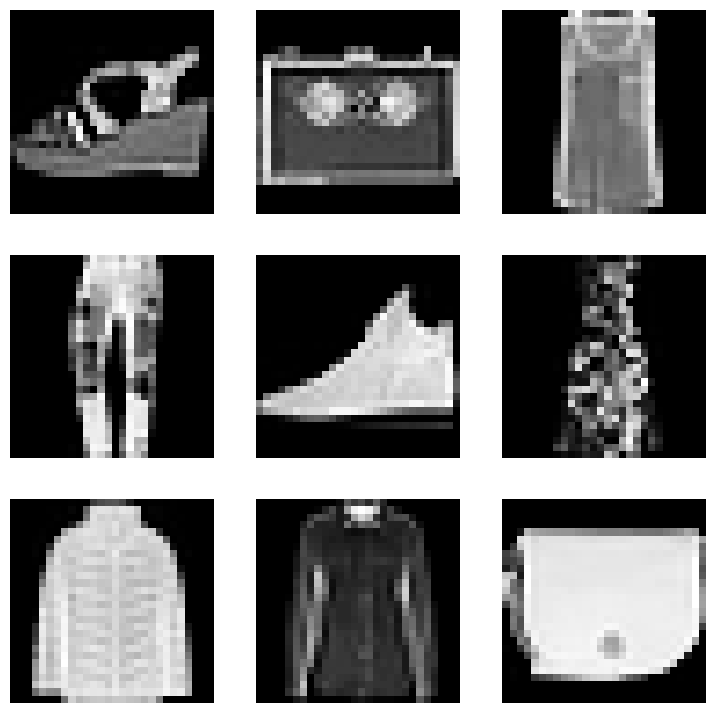

In [6]:
# definindo o tamanho da imagem
plt.figure(figsize=(9,9))

# escolher 9 numeros aleatorios até 60000
rndSamples = np.random.choice(60000, 9)

# plotando as 9 imagens aleatorias do dataset
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[rndSamples[i]], cmap='Greys_r')
    plt.axis('off')

plt.show()

In [ ]:
# juntando os datasets de treino e teste
dataset = np.concatenate([x_train, x_test], axis=0)

# criando mais uma dimensão e normalizando os dados
dataset = np.expand_dims(dataset, -1).astype('float32') / 255

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# criando uma camada de sampling personalizada
class SamplingLayer(layers.Layer):
    def call(self, inputs):

        # media do espaço latente e o logaritmo da variança
        zMean, zLogVar = inputs
        # quantidade de amostras
        batch = tf.shape(zMean)[0]
        # numero de neuronios ocultos
        dim = tf.shape(zMean)[1]
        # cria a matriz de ruído aleatório
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))

        # equação do VAE
        return zMean + tf.exp(0.5 * zLogVar) * epsilon

In [10]:
# criando o encoder
def buildEncoder(latentDim, encoderInputs):

    # modelo sequencial de convolução para extrair as caracteristicas de uma imagem
    l1 = keras.models.Sequential([
        layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),
        layers.Conv2D(64, 3, activation="relu", strides=2, padding="same"),
        layers.Flatten(),
        layers.Dense(256, activation="relu")
    ])

    # passa os inputs para a sequencia de convolução
    x = l1(encoderInputs)

    # uma camada dedicada para aprender a média
    zMean = layers.Dense(latentDim, name="z_mean")(x)

    # camada dedicada para aprender a variancia
    zLogVar = layers.Dense(latentDim, name="z_log_var")(x)

    # encontrando o valor variável através da camada de sampling definida anteriormente
    z = SamplingLayer()([zMean, zLogVar])

    # retornando o encoder com todas as camadas
    return keras.Model(encoderInputs, [zMean, zLogVar, z], name="encoder")


# instancia o modelo
encoderInputs = keras.Input(shape=(28, 28, 1))
encoder = buildEncoder(2, encoderInputs)
encoder.summary()

E0000 00:00:1782994889.595788    1835 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256)       │    878,144 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_layer      │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (SamplingLayer)     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 879,172 (3.35 MB)

 Trainable params: 879,172 (3.35 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# criando o decoder
def buildDecoder(latentInputs):

    # colocando as camadas de transposição (processo inverso a convolução)
    l1 = keras.models.Sequential([
        layers.Dense(7*7*64, activation="relu", input_shape=(latentInputs.shape[1],)),
        layers.Reshape((7,7,64)),
        layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same"),
        layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same"),
        layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")
    ])

    # retorna o modelo construido
    return keras.Model(latentInputs, l1(latentInputs), name="decoder")

# instanciando o decoder
latentInputs = keras.Input(shape=(2,))
decoder = buildDecoder(latentInputs)
decoder.summary()

/home/liperasz/miniconda3/envs/card-27/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │       157,633 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,633 (615.75 KB)

 Trainable params: 157,633 (615.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# função de loss para a reconstrução da imagem
def reconstructionLoss(data, reconstructed):
    # aplica uma penalização caso a imagem reconstruida nao esteja semelhante a original
    return tf.reduce_mean(
        tf.reduce_sum(
            keras.losses.binary_crossentropy(data, reconstructed),
            axis=(1, 2)
        )
    )

In [13]:
# função de loss que aproxima a distribuição de probabilidade da distribuição normal
def klDivergenceLoss(zMean, zLogVar):
    return tf.reduce_mean(
        tf.reduce_sum(
            -0.5 * (1 + zLogVar - tf.square(zMean) - tf.exp(zLogVar)),
            axis=1
        )
    )

In [14]:
# função para calcular a loss total do auto encoder
def calcTotalLoss(data, reconstructed, zMean, zLogVar):
    # calculando as 2 loss
    loss1 = reconstructionLoss(data, reconstructed)
    loss2 = klDivergenceLoss(zMean, zLogVar)
    # peso aplicado a loss kl
    klWeight = 3.0
    return  loss1, loss2, loss1 + klWeight * loss2

In [15]:
# criando o auto encoder variacional
class VAE(keras.Model):

    # parametros da classe
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        # instancia o encoder e o decoder
        self.encoder = encoder
        self.decoder = decoder
        # registra a loss total como uma metrica observavel no historico do treinamento do modelo
        self.totalLossTracker = keras.metrics.Mean(name="total_loss")
        self.ceLossTracker = keras.metrics.Mean(name="ce_loss")
        self.klLossTracker = keras.metrics.Mean(name="kl_loss")
        
    # define as metricas observáveis
    @property
    def metrics(self):
        return [
            self.totalLossTracker,
            self.ceLossTracker,
            self.klLossTracker
        ]

    # função que faz o treinamento (calcular a loss, atualizar os pesos etc)
    def train_step(self, data):
        
        # função gravada pelo tensorflow para calcular o gradiente depois
        with tf.GradientTape() as tape:
            # passa os dados pelo encoder
            zMean, zLogVar, z = self.encoder(data)
            # depois pelo decoder
            reconstruction = self.decoder(z)
            # calcula a loss
            ceLoss, klLoss, totalLoss = calcTotalLoss(data, reconstruction, zMean, zLogVar)
        
        # calcula os gradientes
        grads = tape.gradient(totalLoss, self.trainable_weights)
        # atualiza os pesos
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # atualiza as metricas
        self.totalLossTracker.update_state(totalLoss)
        self.ceLossTracker.update_state(ceLoss)
        self.klLossTracker.update_state(klLoss)

        # retorna os resultados
        return {
            "total_loss": self.totalLossTracker.result(),
            "ce_loss": self.ceLossTracker.result(),
            "kl_loss": self.klLossTracker.result()
        }

In [16]:
# instanciando o autoencoder
vae = VAE(encoder, decoder)
# compilando
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))
# treinando
history = vae.fit(dataset, epochs=32, batch_size=128)

Epoch 1/32


W0000 00:00:1782996746.214127    1835 cpu_allocator_impl.cc:82] Allocation of 219520000 exceeds 10% of free system memory.


547/547 ━━━━━━━━━━━━━━━━━━━━ 108s 192ms/step - ce_loss: 300.7993 - kl_loss: 3.7650 - total_loss: 312.0941
Epoch 2/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 104s 190ms/step - ce_loss: 266.1024 - kl_loss: 4.5399 - total_loss: 279.7222
Epoch 3/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 102s 187ms/step - ce_loss: 261.7354 - kl_loss: 4.6734 - total_loss: 275.7555
Epoch 4/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 102s 186ms/step - ce_loss: 259.2053 - kl_loss: 4.7711 - total_loss: 273.5186
Epoch 5/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 99s 182ms/step - ce_loss: 257.8651 - kl_loss: 4.8412 - total_loss: 272.3885
Epoch 6/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 109s 198ms/step - ce_loss: 256.7707 - kl_loss: 4.8820 - total_loss: 271.4167
Epoch 7/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 105s 192ms/step - ce_loss: 256.1860 - kl_loss: 4.9340 - total_loss: 270.9880
Epoch 8/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 101s 185ms/step - ce_loss: 255.3547 - kl_loss: 4.9774 - total_loss: 270.2868
Epoch 9/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 94s 172ms/step - ce_loss: 254.9078 -

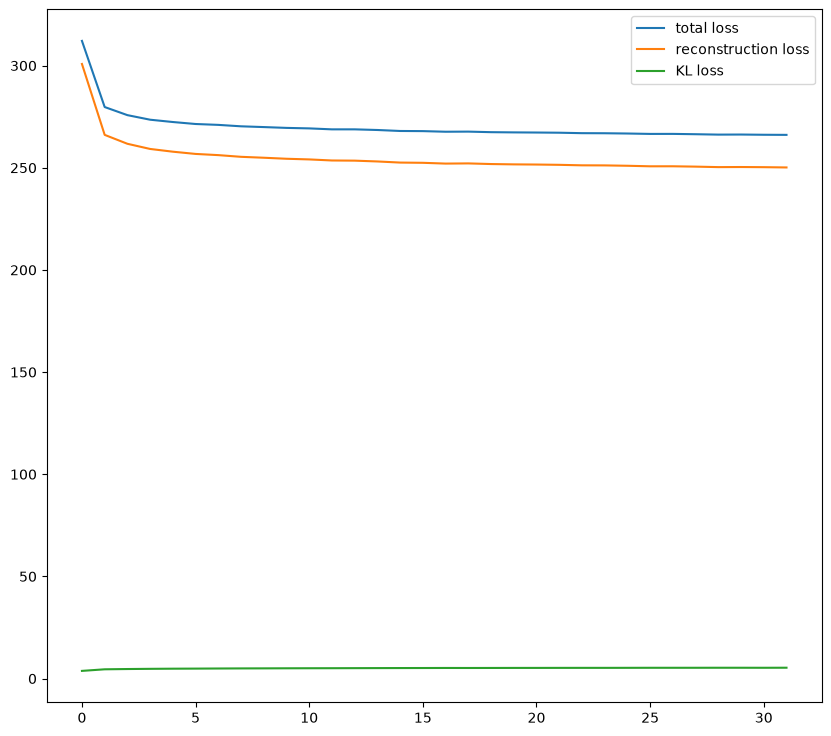

In [17]:
# plotando o historico do treinamento
plt.figure(figsize=(10, 9))
plt.plot(history.history.get('total_loss'), label="total loss")
plt.plot(history.history.get('ce_loss'), label="reconstruction loss")
plt.plot(history.history.get('kl_loss'), label="KL loss")
plt.legend();

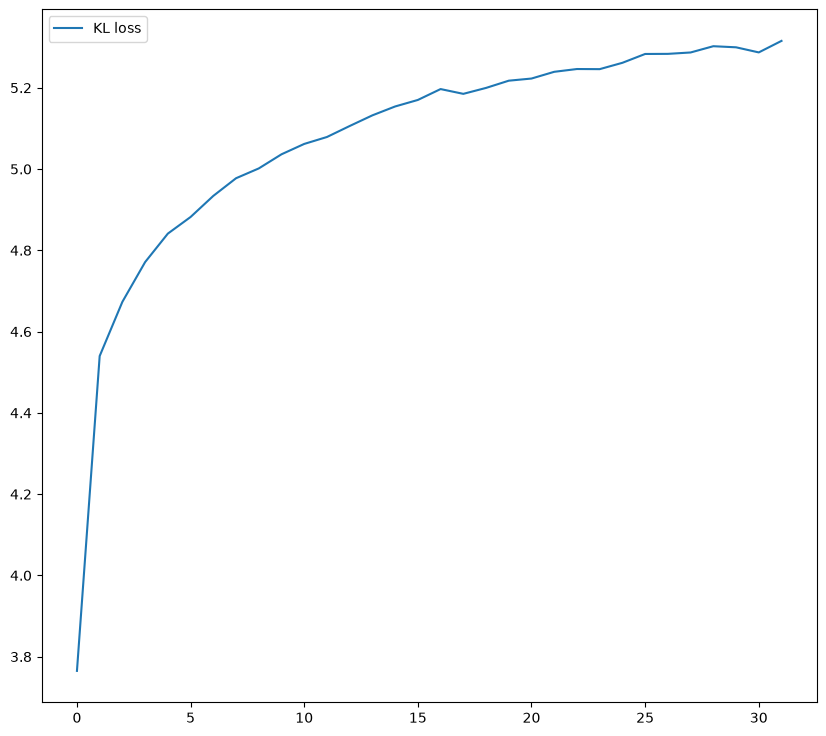

In [19]:
# plotando o kl loss
plt.figure(figsize=(10, 9))
plt.plot(history.history.get('kl_loss'), label="KL loss")
plt.legend();

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


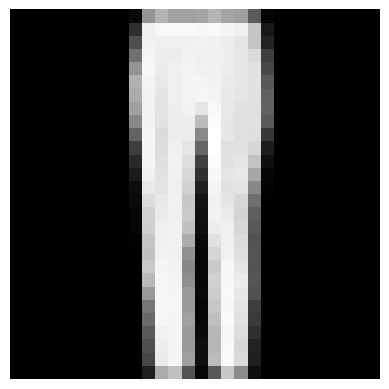

In [27]:
# fazendo uma previsão de imagem
synth = vae.decoder.predict(np.array([[1, 2]]))
plt.axis('off')
plt.imshow(synth.reshape((28,28)), cmap="Greys_r");

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


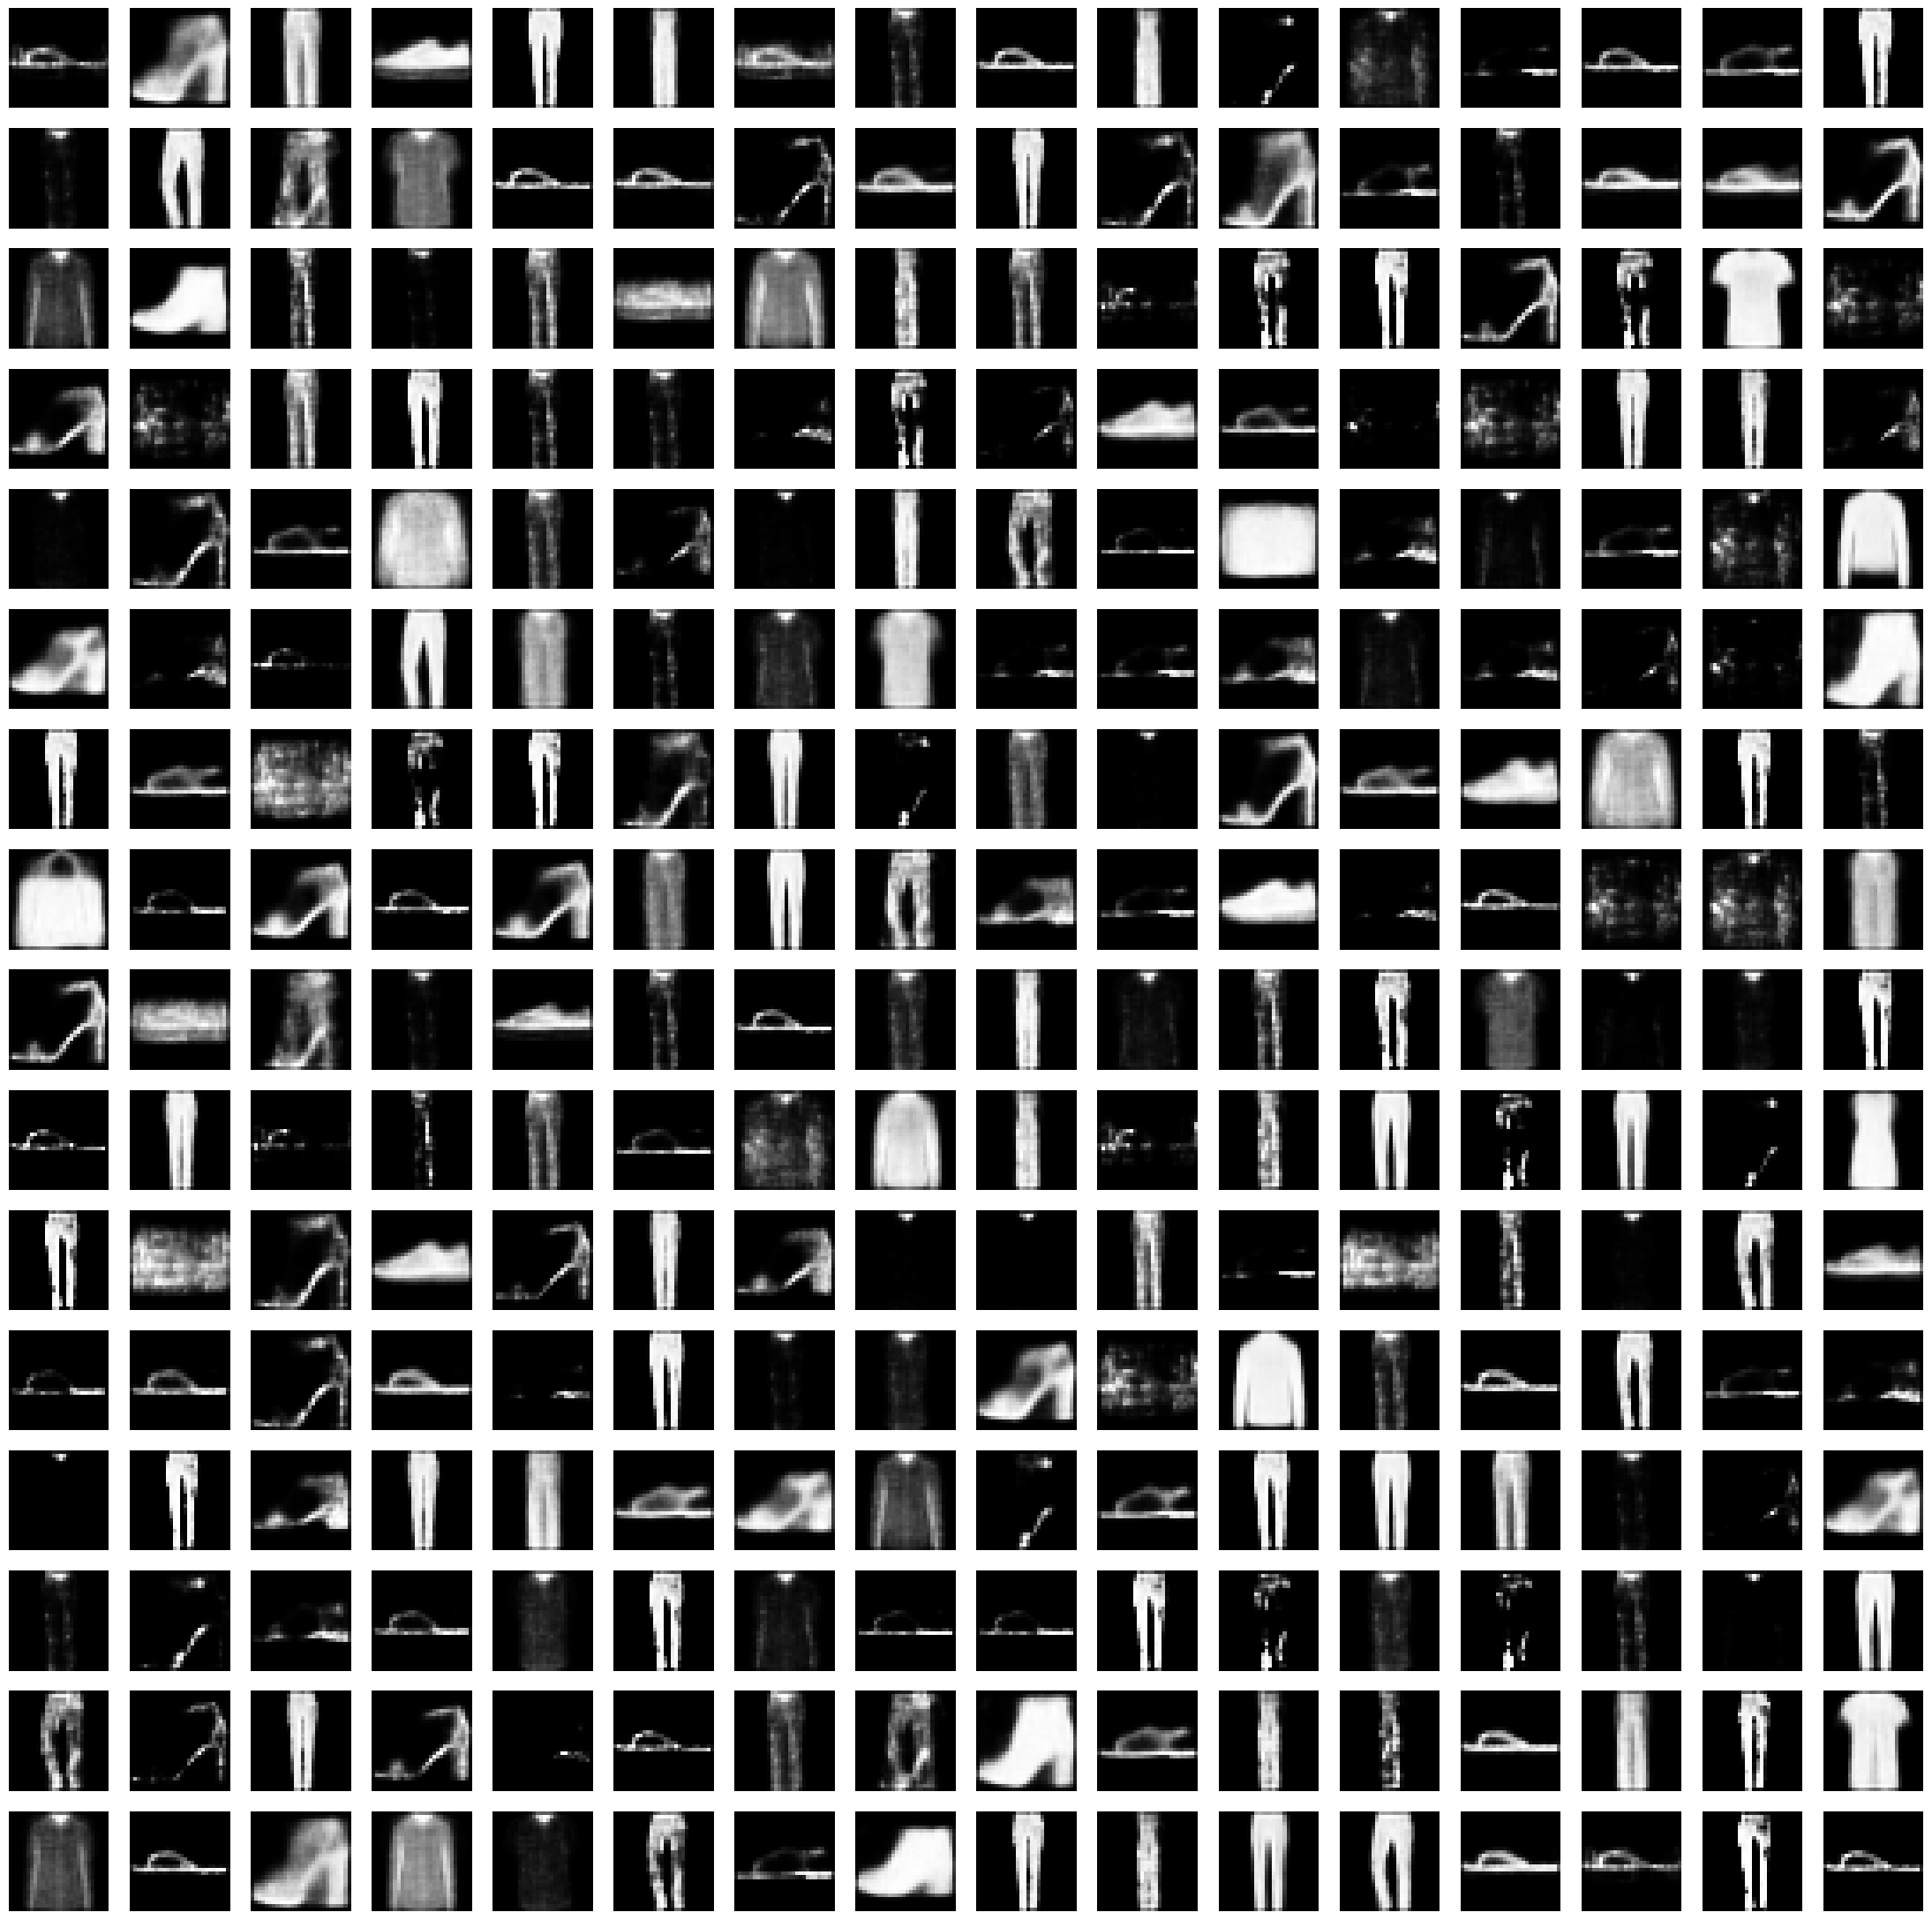

In [28]:
# gerando valores aleatorios para z de acordo com a distribuicao normal
z = np.random.normal(loc=0, scale=4, size=(256,2))
# fazendo as previsoes
synth = vae.decoder.predict(z)

# plotando as imagens
plt.figure(figsize=(28,28))

for i in range(256):
    plt.subplot(16,16,i+1)
    plt.imshow(synth[i].reshape((28,28)), cmap="Greys_r")
    plt.axis('off')

plt.show();

In [32]:
# index
idx = 1280
# pegando a imagem
batch = np.expand_dims(x_train[idx], axis=0)
batchOfImages = np.expand_dims(batch, axis=-1).astype("float32") / 255
print(batchOfImages.shape)

# obtem o z para as imagens
_, _, z = vae.encoder.predict(batchOfImages)

# reconstroi a imagem semelhante
synth = vae.decoder.predict([z])

z

(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[0.08866195, 1.3390083 ]], dtype=float32)

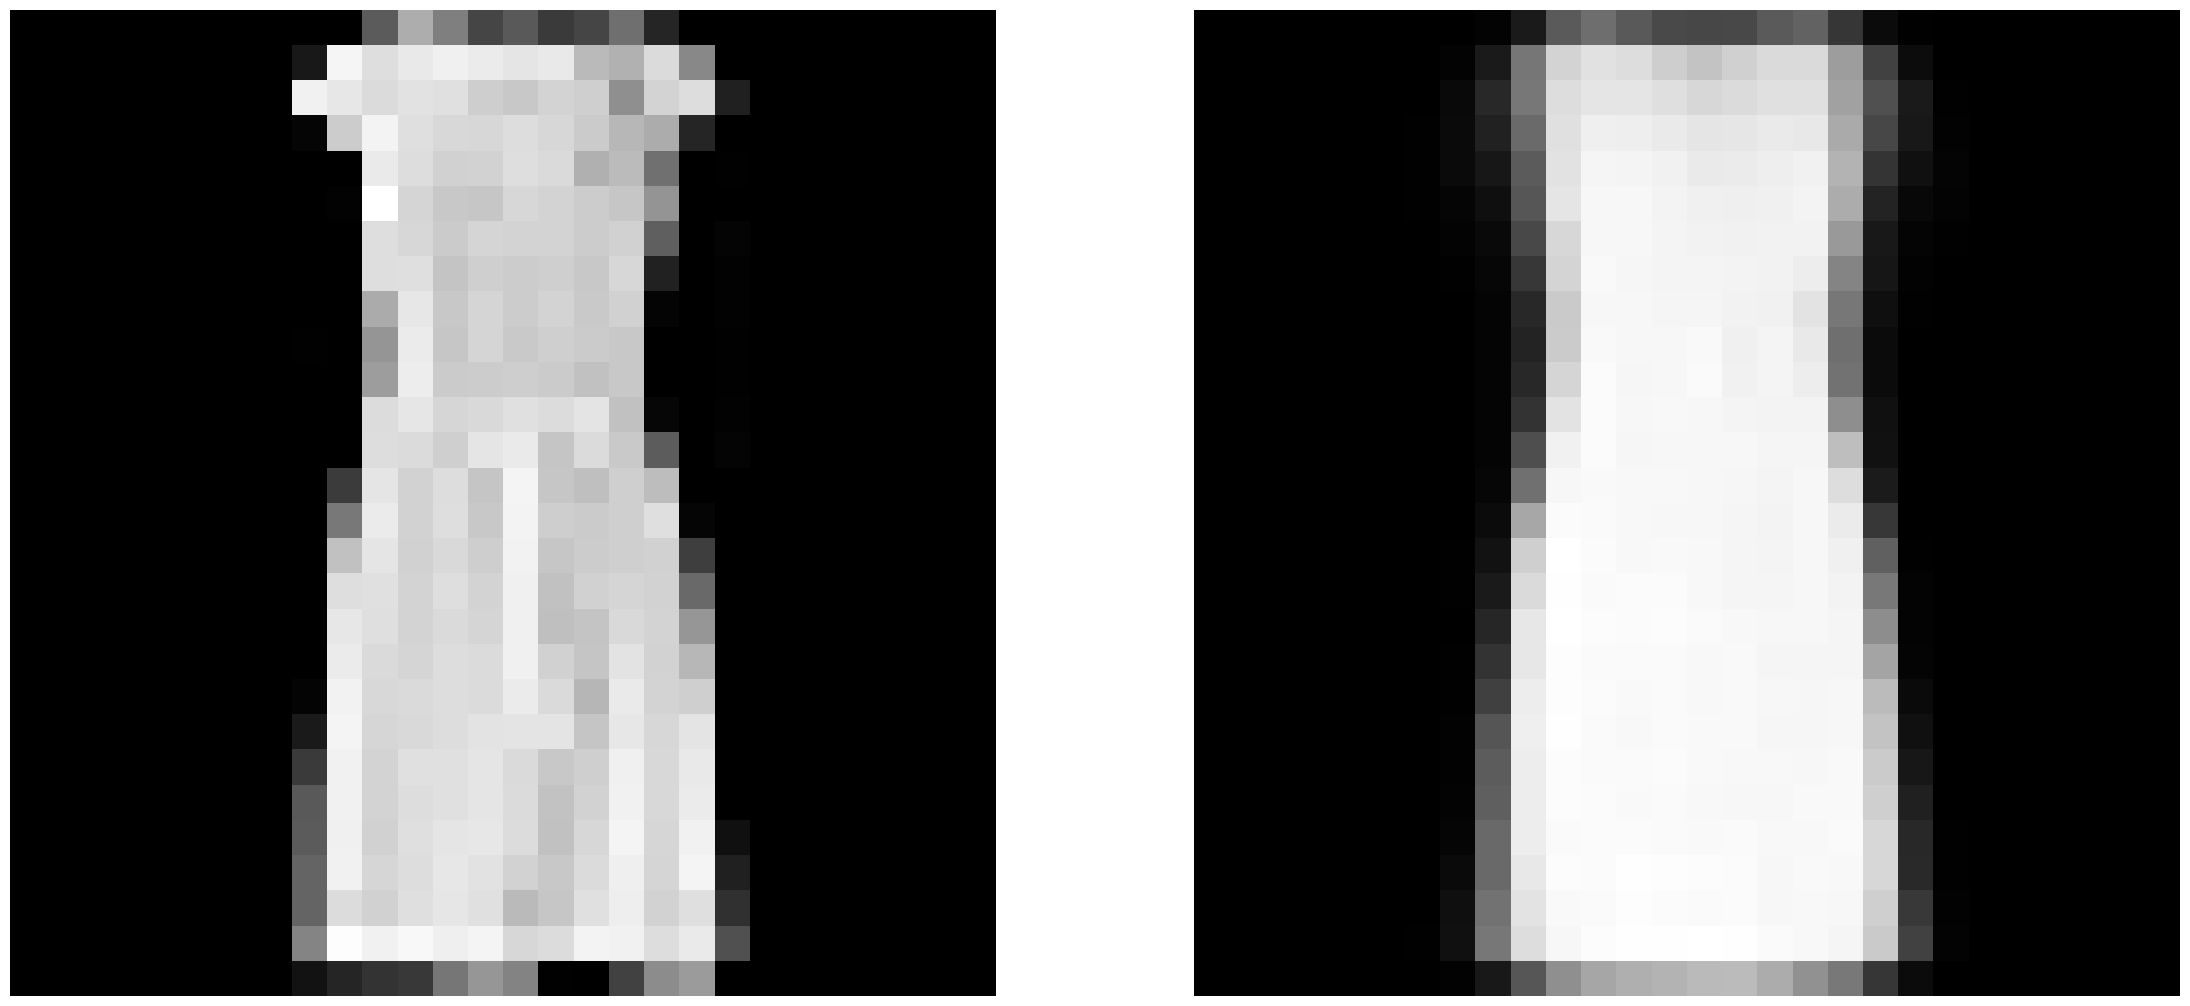

In [33]:
plt.figure(figsize=(28, 28))

# imagem original
plt.subplot(1,2,1)
plt.axis('off')
plt.imshow(x_train[idx], cmap="Greys_r")


# reconstruida
plt.subplot(1,2,2)
plt.axis('off')
plt.imshow(synth[0].reshape((28,28)), cmap="Greys_r")
plt.show();

  33/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step

W0000 00:00:1783000598.339225    1835 cpu_allocator_impl.cc:82] Allocation of 219520000 exceeds 10% of free system memory.


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step


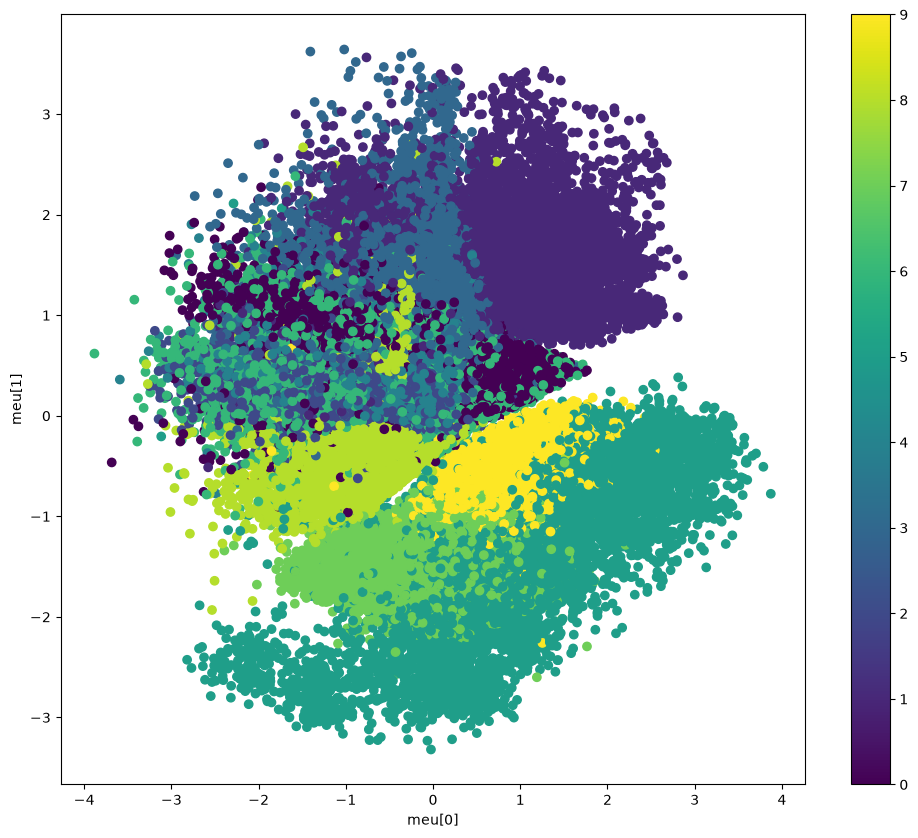

In [35]:
# juntando todas os datasets
labels = np.concatenate([y_train, y_test], axis=0)
# pegando os valores previstos pelo encoder
meu, _, _ = vae.encoder.predict(dataset)
# plotando para ver as probabilidades para cada classe
plt.figure(figsize=(12, 10))
plt.scatter(meu[:, 0], meu[:, 1], c=labels)
plt.colorbar()
plt.xlabel("meu[0]")
plt.ylabel("meu[1]")
plt.show();